## Financial Data Analysis with PySpark Part 2

In [1]:
from pyspark.sql import SparkSession, functions
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder.appName('stock_price_analysis').getOrCreate()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [3]:
df = spark.read.csv('World-Stock-Prices-Dataset.csv', header=True, inferSchema=True)

In [4]:
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Brand_Name: string (nullable = true)
 |-- Ticker: string (nullable = true)
 |-- Industry_Tag: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)
 |-- Capital Gains: double (nullable = true)



In [8]:
industry_df = df.select(['Industry_Tag', 'Open', 'Close']).groupBy('Industry_Tag').mean().toPandas()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [9]:
industry_df

,Industry_Tag,avg(Open),avg(Close)
0,social media,34.782465,34.800216
1,automotive,58.882701,58.880424
2,finance,102.206098,102.234627
3,technology,61.110693,61.119638
4,financial services,81.740414,81.682269
5,food,326.240821,326.263032
6,apparel,41.117748,41.088794
7,hospitality,90.416620,90.455514
8,luxury goods,60.628983,60.692655
9,manufacturing,87.804787,87.809660


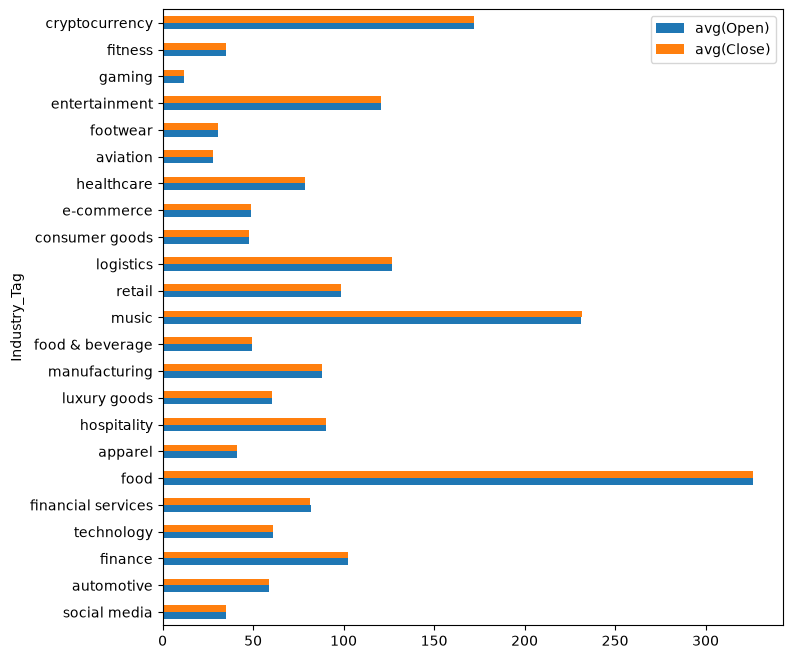

In [10]:
industry_df.plot(kind='barh', x='Industry_Tag', y=tag_df.columns.tolist()[1:],
           figsize=(8,8));

In [11]:
industry_df_no_music_food = industry_df[(industry_df['Industry_Tag'] != 'music') & (industry_df['Industry_Tag'] != 'food')]

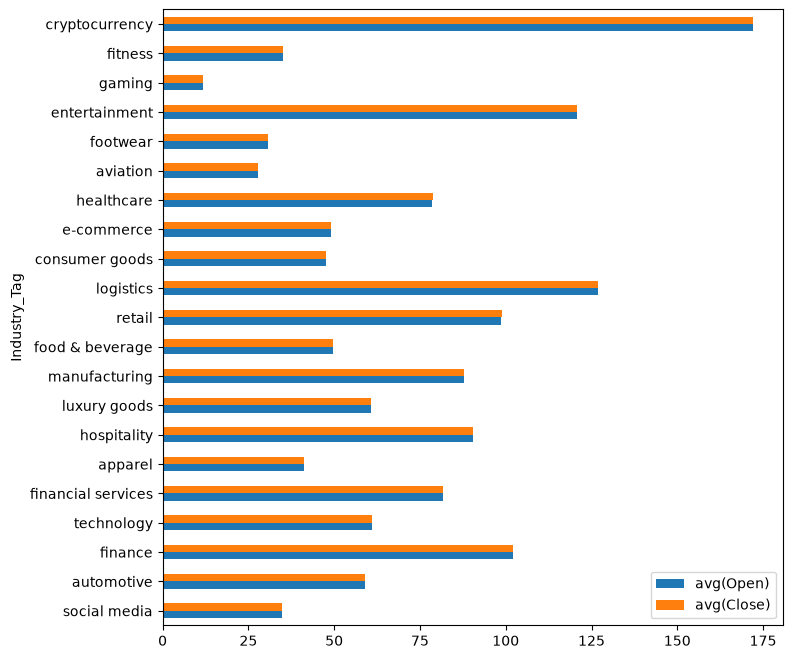

In [12]:
industry_df_no_music_food.plot(kind='barh', x='Industry_Tag', y=tag_df.columns.tolist()[1:],
           figsize=(8,8));

In [14]:
import pyspark.sql.functions as f

In [17]:
health = df.filter(f.col('Industry_Tag')=='healthcare')
health.show(5)

+-------------------+------------------+------------------+------------------+------------------+---------+-----------------+------+------------+-------+---------+------------+-------------+
|               Date|              Open|              High|               Low|             Close|   Volume|       Brand_Name|Ticker|Industry_Tag|Country|Dividends|Stock Splits|Capital Gains|
+-------------------+------------------+------------------+------------------+------------------+---------+-----------------+------+------------+-------+---------+------------+-------------+
|2025-07-03 09:30:00|155.42999267578125|156.27999877929688| 154.8800048828125|156.00999450683594|3363171.0|johnson & johnson|   JNJ|  healthcare|    usa|      0.0|         0.0|         NULL|
|2025-07-03 09:30:00|155.42999267578125|156.27999877929688| 154.8800048828125|156.00999450683594|3482500.0|johnson & johnson|   JNJ|  healthcare|    usa|      0.0|         0.0|         NULL|
|2025-07-02 09:30:00|             156.0| 156.

In [18]:
## Start/End Date, min, max, avg
from pyspark.sql.functions import col, min, max, avg

In [20]:
df.groupBy('Industry_Tag').agg(min('Date').alias('Start'),
                              max('Date').alias('End'),
                              
                              min('Open').alias('Min. Open'),
                              max('Open').alias('Max. Open'),
                              avg('Open').alias('Avg. Open'),

                              min('Close').alias('Min. Close'),
                              max('Close').alias('Max. Close'),
                              avg('Close').alias('Avg. Close'),
                            ).show(truncate=False)

+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Industry_Tag      |Start              |End                |Min. Open         |Max. Open         |Avg. Open         |Min. Close        |Max. Close        |Avg. Close        |
+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|social media      |2019-04-18 09:30:00|2025-07-03 09:30:00|0.0               |87.41000366210938 |34.78246475769062 |10.920000076293944|89.1500015258789  |34.80021632528128 |
|automotive        |2000-01-03 10:30:00|2025-07-03 09:30:00|1.0759999752044678|475.8999938964844 |58.88270088469111 |1.053333044052124 |479.8599853515625 |58.88042419762223 |
|finance           |2000-01-03 10:30:00|2025-07-03 09:30:00|3.709897789251644 |590.3200073242188 |102.20609774369709|4.041300

In [21]:
tech = df.where(col('Industry_Tag') == 'technology').select('Date', 'Open', 'Close')

In [23]:
tech.show()

+-------------------+------------------+------------------+
|               Date|              Open|             Close|
+-------------------+------------------+------------------+
|2025-07-03 09:30:00| 212.1450042724609| 213.5500030517578|
|2025-07-03 09:30:00|178.69500732421875|179.52999877929688|
|2025-07-03 09:30:00|  77.5999984741211| 78.58000183105469|
|2025-07-03 09:30:00|158.35000610351562|159.33999633789062|
|2025-07-03 09:30:00|269.70001220703125| 272.1499938964844|
|2025-07-03 09:30:00| 92.44000244140624| 92.69000244140624|
|2025-07-03 09:30:00|139.11000061035156|137.91000366210938|
|2025-07-03 09:30:00|             378.0|379.30999755859375|
|2025-07-03 09:30:00| 68.19999694824219| 69.37000274658203|
|2025-07-03 09:30:00| 92.62999725341795| 93.62999725341795|
|2025-07-03 09:30:00| 24.31999969482422|24.170000076293945|
|2025-07-03 09:30:00| 493.4949951171875| 498.8399963378906|
|2025-07-03 09:30:00|             378.0|379.30999755859375|
|2025-07-03 09:30:00| 68.18000030517578|

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


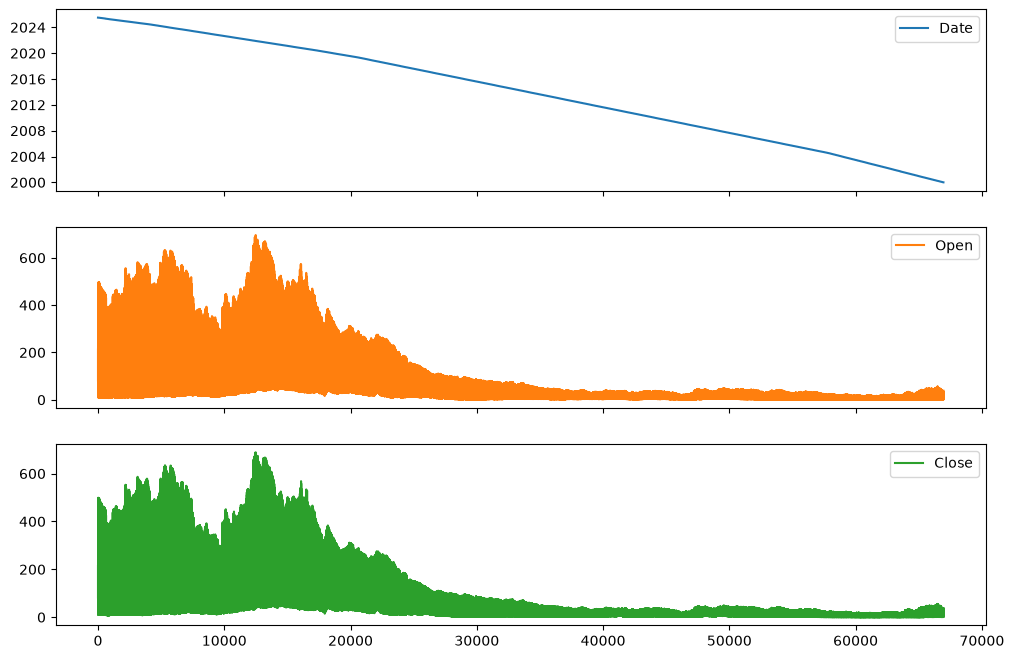

In [22]:
tech.toPandas().plot(subplots=True, figsize=(12,8));

In [24]:
df.show()

+-------------------+------------------+------------------+------------------+------------------+------------+--------------------+------+---------------+-------+---------+------------+-------------+
|               Date|              Open|              High|               Low|             Close|      Volume|          Brand_Name|Ticker|   Industry_Tag|Country|Dividends|Stock Splits|Capital Gains|
+-------------------+------------------+------------------+------------------+------------------+------------+--------------------+------+---------------+-------+---------+------------+-------------+
|2025-07-03 09:30:00| 6.630000114440918| 6.739999771118164| 6.614999771118164| 6.639999866485596|   4209664.0|             peloton|  PTON|        fitness|    usa|      0.0|         0.0|         NULL|
|2025-07-03 09:30:00|            106.75|108.37000274658205| 106.3301010131836|107.33999633789062|    560190.0|               crocs|  CROX|       footwear|    usa|      0.0|         0.0|         NULL|


In [25]:
df.filter(df['Close'].between(100,500)).show(5)

+-------------------+------------------+------------------+------------------+------------------+-----------+----------+------+------------+-------+---------+------------+-------------+
|               Date|              Open|              High|               Low|             Close|     Volume|Brand_Name|Ticker|Industry_Tag|Country|Dividends|Stock Splits|Capital Gains|
+-------------------+------------------+------------------+------------------+------------------+-----------+----------+------+------------+-------+---------+------------+-------------+
|2025-07-03 09:30:00|            106.75|108.37000274658205| 106.3301010131836|107.33999633789062|   560190.0|     crocs|  CROX|    footwear|    usa|      0.0|         0.0|         NULL|
|2025-07-03 09:30:00|122.62999725341795| 123.0500030517578| 121.5500030517578|121.93000030517578|    36600.0|    adidas| ADDYY|     apparel|germany|      0.0|         0.0|         NULL|
|2025-07-03 09:30:00| 221.7050018310547|224.00999450683597| 221.360000

In [26]:
from pyspark.sql.functions import lit

In [28]:
df.filter((col('Date') >= lit('2025-01-01')) & (col('Date') <= lit('2025-01-31'))).show(5)

+-------------------+------------------+------------------+------------------+------------------+-----------+----------------+------+--------------+-------+---------+------------+-------------+
|               Date|              Open|              High|               Low|             Close|     Volume|      Brand_Name|Ticker|  Industry_Tag|Country|Dividends|Stock Splits|Capital Gains|
+-------------------+------------------+------------------+------------------+------------------+-----------+----------------+------+--------------+-------+---------+------------+-------------+
|2025-01-30 10:30:00| 118.4800033569336|120.44000244140624|117.08999633789062|118.86000061035156|2.9345608E7|             amd|   AMD|    technology|    usa|      0.0|         0.0|         NULL|
|2025-01-30 10:30:00|             317.0| 321.8940124511719|             316.0|318.95001220703125|  1921393.0|american express|   AXP|       finance|    usa|      0.0|         0.0|         NULL|
|2025-01-30 10:30:00|         

In [30]:
df.select('Open', 'Close', f.when(df['Close']>=200, 1).otherwise(0).alias('strat')).show()

+------------------+------------------+-----+
|              Open|             Close|strat|
+------------------+------------------+-----+
| 6.630000114440918| 6.639999866485596|    0|
|            106.75|107.33999633789062|    0|
|122.62999725341795|121.93000030517578|    0|
| 221.7050018310547|223.41000366210935|    1|
| 212.1450042724609| 213.5500030517578|    1|
| 76.26499938964844| 76.38999938964844|    0|
| 105.9499969482422|104.05999755859376|    0|
|178.69500732421875|179.52999877929688|    0|
|             713.0| 725.0499877929688|    1|
|  77.5999984741211| 78.58000183105469|    0|
|123.06500244140624|             124.0|    0|
|102.41000366210938|103.58999633789062|    0|
|              50.5| 50.86000061035156|    0|
| 982.4000244140624|   987.02001953125|    1|
|              34.0| 34.08000183105469|    0|
|10.300000190734863|10.279999732971191|    0|
|317.95001220703125| 315.3500061035156|    1|
|  94.1999969482422| 94.44000244140624|    0|
|158.35000610351562|159.3399963378

In [37]:
df.select('Industry_Tag', df['Industry_Tag'].rlike('^[a,b]').alias('Industry Sector Starts with A or B')).distinct().show()

+------------------+----------------------------------+
|      Industry_Tag|Industry Sector Starts with A or B|
+------------------+----------------------------------+
|    cryptocurrency|                             false|
|            gaming|                             false|
|financial services|                             false|
|              food|                             false|
|    consumer goods|                             false|
|           apparel|                              true|
|        healthcare|                             false|
|     entertainment|                             false|
|        e-commerce|                             false|
|         logistics|                             false|
|        technology|                             false|
|            retail|                             false|
|        automotive|                              true|
|          aviation|                              true|
|      luxury goods|                            